In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


**LOAD DATASET**

In [31]:
df = pd.read_csv("HousingData.csv")

In [32]:
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


**DROP "MEDV" AS WO TARGET HAI BAKI SAB FEATURES HAI AXIS=1 MATLAB COLUMN NAMES**

In [33]:
df = df.fillna(df.median())

In [34]:
X = df.drop("MEDV",axis =1)

In [35]:
y = df["MEDV"]

**Data ko train aur test me divide karne ke liye**
**random_state=42 → same result baar-baar aaye (reproducibility)**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size = 0.3, random_state = 42
)

**Linear regression obj creation**

In [37]:
model = LinearRegression()

**training the model**

In [38]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Har feature ka weight batata h**

In [40]:
model.coef_

array([-1.24672220e-01,  3.03594095e-02, -7.93208343e-03,  3.73930575e+00,
       -1.38772982e+01,  4.38363745e+00, -2.43295727e-02, -1.40721120e+00,
        1.90584276e-01, -7.08795497e-03, -8.90430534e-01,  1.15287229e-02,
       -4.81030379e-01])

**Bias term b (Intercept) when all feature value is 0**

In [41]:
model.intercept_


np.float64(29.095854539586586)

**Prediction**

y_pred = model.predict(X_test)


**Mean Squared Error if kam model is better ✅**

In [43]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

21.784360758791355


**R^2 Score**
**Batata hai kitna variance explain ho raha**
**Higher R² indicates better goodness of fit.**

In [44]:
r2 = r2_score(y_test, y_pred)
print(r2)


0.7076438632327385


**Prediction vs Reality samajhne ke liye**

In [48]:
y_pred[:5]



array([28.74796697, 37.04276981, 15.23648947, 25.57965227, 18.4598692 ])

In [49]:
y_test.values[:5]

array([23.6, 32.4, 13.6, 22.8, 16.1])

**Prediction ko table me dekhna**

In [51]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:5],
    "Predicted Price": y_pred[:5]
})

comparison


,Actual Price,Predicted Price
0,23.6,28.747967
1,32.4,37.042770
2,13.6,15.236489
3,22.8,25.579652
4,16.1,18.459869


**NEW house ka price predict karna (IMPORTANT)**
**Sklearn expects 2D input**

In [52]:
new_house = np.array([[ 
    0.00632,   # CRIM
    18.0,      # ZN
    2.31,      # INDUS
    0.0,       # CHAS
    0.538,     # NOX
    6.575,     # RM
    65.2,      # AGE
    4.09,      # DIS
    1,         # RAD
    296,       # TAX
    15.3,      # PTRATIO
    396.9,     # B
    4.98       # LSTAT
]])


In [53]:
predicted_price = model.predict(new_house)


C:\Users\Siddhi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**Tumne model DataFrame (with column names) se train kiya**
**But prediction ke time NumPy array (without column names) diya**

**Sklearn bol raha:**

**“Bhai, training me mujhe column names mile the, ab prediction me nahi mil rahe."**

In [54]:
print("Predicted House Price:", predicted_price[0])


Predicted House Price: 30.287041994247872


**Polynomial Regression on a new Dataset**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
diabetes = load_diabetes()


In [3]:
X = diabetes.data[:, np.newaxis, 2]
y = diabetes.target

In [4]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)


In [5]:
model = LinearRegression()
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred = model.predict(X_poly)

In [7]:
sorted_index = np.argsort(X[:, 0])
X_sorted = X[sorted_index]
y_sorted_pred = y_pred[sorted_index]

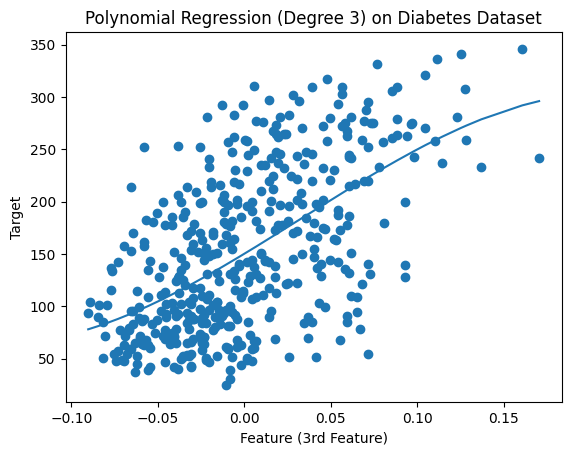

In [8]:
plt.scatter(X, y)
plt.plot(X_sorted, y_sorted_pred)
plt.xlabel("Feature (3rd Feature)")
plt.ylabel("Target")
plt.title("Polynomial Regression (Degree 3) on Diabetes Dataset")
plt.show()

In [9]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

In [10]:
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 3883.3511785367314
R-squared (R²): 0.34512199713015446


**This model explains 34.5% of the variance**

**Around 65.5% of variation is unexplained**

**For single-feature regression, this is actually reasonable.**